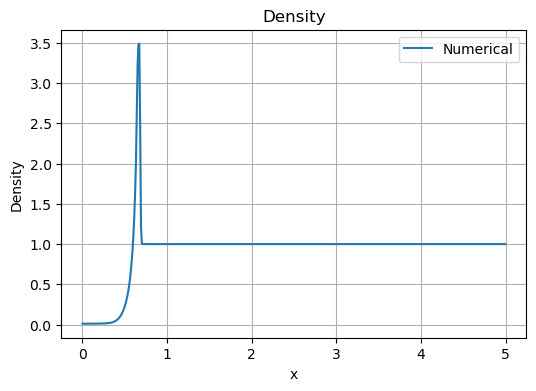

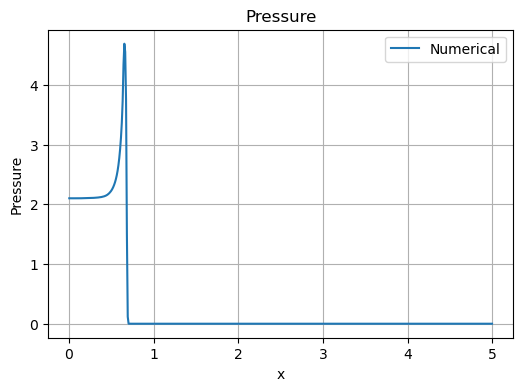

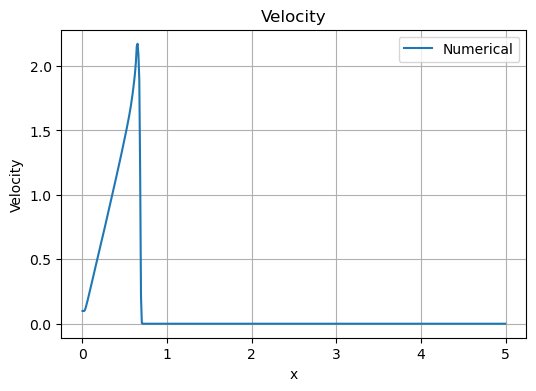

alpha = 0.39639616330036626


In [2]:
import sys
sys.path.append("../src")
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

import hll_euler_eq_solver as h


# ============================================================
# Parameters
# ============================================================

gamma = 1.4

dt = 0.00001
N = 500
dx = 0.01

x = (np.arange(N) + 0.5) * dx

t = 0.0
t_end = 0.1


# ============================================================
# Solver
# ============================================================

solver = h.HLL_Euler_Eq_Solver(
    dt=dt,
    dx=dx,
    gamma=gamma
)


# ============================================================
# Initial conditions
# ============================================================

U = np.zeros((N, 3))

p0 = 1000
rho0 = 1.0

for i in range(N):

    if x[i] <= 0.1:
        rho = rho0
        v = 0.0
        p = p0

    else:
        rho = 1.0
        v = 0.0
        p = 1e-6

    momentum = rho * v

    E = (
        p / (gamma - 1)
        + 0.5 * rho * v**2
    )

    U[i] = [rho, momentum, E]


# ============================================================
# Track shock position
# ============================================================

times = []
radii = []


while t < t_end:

    U = solver.time_step_spherical(U)

    t += dt

    rho = U[:, 0]

    # Estimate shock position from maximum density gradient
    gradient_rho = np.gradient(rho, x)

    R = x[np.argmax(np.abs(gradient_rho))]

    times.append(t)
    radii.append(R)


times = np.array(times)
radii = np.array(radii)


# ============================================================
# Extract primitive variables
# ============================================================

rho = U[:, 0]
momentum = U[:, 1]
E = U[:, 2]

v = momentum / rho

p = (gamma - 1) * (
    E - momentum**2 / (2 * rho)
)


# ============================================================
# Similarity variables
# ============================================================

xi_num = x / radii[-1]

# Current shock radius and time
R = radii[-1]
t = times[-1]

# Shock velocity from Sedov-Taylor scaling
v_shock = 2 * R / (5 * t)

# Post-shock density
rho_shock = rho0 * (gamma + 1) / (gamma - 1)

# Post-shock pressure
p_shock = (
    2 * rho0 * v_shock**2
    / (gamma + 1)
)

# Temperature normalization
# T is proportional to p / rho
T_shock = p_shock / rho_shock


# Normalized variables

v_norm = v / v_shock

rho_norm = rho / rho_shock

p_norm = p / p_shock

T_norm = (p / rho) / T_shock


# ============================================================
# Plot density
# ============================================================

plt.figure(figsize=(6, 4))

plt.plot(
    x,
    rho,
    label="Numerical"
)

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Density")

plt.grid()
plt.legend()

plt.show()


# ============================================================
# Plot pressure
# ============================================================

plt.figure(figsize=(6, 4))

plt.plot(
    x,
    p,
    label="Numerical"
)

plt.xlabel("x")
plt.ylabel("Pressure")
plt.title("Pressure")

plt.grid()
plt.legend()

plt.show()


# ============================================================
# Plot velocity
# ============================================================

plt.figure(figsize=(6, 4))

plt.plot(
    x,
    v,
    label="Numerical"
)

plt.xlabel("x")
plt.ylabel("Velocity")
plt.title("Velocity")

plt.grid()
plt.legend()

plt.show()


# ============================================================
# Measure Sedov-Taylor scaling exponent
# ============================================================

mask = times > 0.05

fit = linregress(
    np.log(times[mask]),
    np.log(radii[mask])
)

print("alpha =", fit.slope)


